<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/FeatureEng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IMPORTANT :


In [52]:
# path = '/content/drive/MyDrive/Thesis_Data/'
path = '../Thesis_Data/'




## 🐄 Feature Engineering & Data Cleaning Pipeline

This section outlines the transformation, calculation, and filtering steps required to prepare the raw dataset for modeling.

### 1. Data Transformation (Scaling)
Standardize the primary yield components to their proper decimal scales:
*   **Milk Yield:** `milk_kg` = $\frac{milk\_kg}{10}$
*   **Fat Percentage:** `fat_p` = $\frac{fat\_p}{100}$
*   **Protein Percentage:** `protein_p` = $\frac{protein\_p}{100}$

---

### 2. Feature Engineering (New Variables)
We derive biological and performance indicators using the following formulas:

| Variable | Description | Formula |
| :--- | :--- | :--- |
| **AFC** | Age at First Calving | $DTC - DTB$ |
| **DIM** | Days In Milk | $DTT - DTC$ |
| **ECM** | Energy Corrected Milk | $[((Fat \times 10) - 40) + ((Protein \times 10) - 31)] \times 0.01155 + 1) \times milk$ |
| **SCS** | Somatic Cell Score | $\log_2(\frac{cells}{100}) + 3$ |

---

### 3. Primary Data Filters
To ensure biological plausibility and data quality, records must satisfy the following constraints:

*   **Production Limits:**
    *   $0.4 \leq \text{Milk} \leq 26.5$
    *   $1.6 \leq \text{Fat} \leq 15.05$
    *   $2.67 \leq \text{Protein} \leq 6.68$
    *   $-2.06 \leq \text{SCS} \leq 10.73$
*   **Zero-Value Guard:** $ECM \leq 30$ AND ($\text{Protein, Fat, Milk} \neq 0$)
*   **Lifecycle & Parity:**
    *   $720 \leq \text{AFC} \leq 1440$
    *   $0 < \text{DIM} \leq 365$
    *   $NM = 2$ (Specific Parity/Management group)

*   **Milk & Protein Lag:** 
    * Lags: 1-record, 2-record.

---

### 4. Final Quality Assurance (Outlier Removal)
The final step removes low-density data points to ensure statistical significance:
1.  **Farm Level:** Remove any farms with **< 5 records** per day.
2.  **Animal Level:** Remove any individual animals with **< 3 total test records**.

---

### 5. Merging with Weather & Environmental Features
For each weather metric (**Temperature, Humidity, Wind, THI1, THI2, WHI**), 

*   **Temporal Lags:** 1-day, 2-day, and 3-day lags (e.g., `avg-lag1`).
*   **Composite Index:** **THI Compose** calculated using a **5-day rolling window** to capture cumulative heat stress.

---


## Load Animal Data


Load the dataset from **path** + 'Dati_ok.txt' into a pandas DataFrame.


In [53]:
datasetAnimalPath = path + 'Dati_ok.txt'

In [54]:
import pandas as pd

col_names = [
    'Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt',
    'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM'
]

cleaned_rows = []

with open(datasetAnimalPath, 'r') as file:
    next(file)

    for line in file:
        line = line.strip()

        if not line:
            continue

        parts = line.split(',')

        if len(parts) == 11:
            cleaned_rows.append(parts)

        elif len(parts) == 12:
            parts.pop(2)
            cleaned_rows.append(parts)

df_animal = pd.DataFrame(cleaned_rows, columns=col_names)

numeric_cols = ['Farm_Code','parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']
for col in numeric_cols:
    df_animal[col] = pd.to_numeric(df_animal[col], errors='coerce')

date_cols = ['dtb', 'dtc', 'dtt']
for col in date_cols:
    df_animal[col] = pd.to_datetime(df_animal[col], format='%Y%m%d', errors='coerce')

print(df_animal.head(5))
print(f"\nTotal rows loaded: {len(df_animal)}")

   Farm_Code       Animal_ID        dtb        dtc        dtt  parity  \
0     521513  IT003990094624 2013-10-29 2022-06-07 2022-06-20       6   
1     521513  IT003990094624 2013-10-29 2022-06-07 2022-07-19       6   
2     521513  IT003990094624 2013-10-29 2022-06-07 2022-09-12       6   
3     521513  IT003990094624 2013-10-29 2022-06-07 2022-10-13       6   
4     521513  IT003990094624 2013-10-29 2022-06-07 2022-11-15       6   

   milk_kg  fat_p  protein_p  cells  NM  
0      141    617        484    656   2  
1      168    682        417    827   2  
2      134    763        459   1144   2  
3      108    663        454   1403   2  
4       94    688        451   1805   2  

Total rows loaded: 2593267


In [83]:
# Keep df_animal as the untouched raw reference for comparison plots
df = df_animal.copy()


## 1. Data Transformation (Scaling)
Standardize the primary yield components to their proper decimal scales:
*   **Milk Yield:** `milk_kg` = $\frac{milk\_kg}{10}$
*   **Fat Percentage:** `fat_p` = $\frac{fat\_p}{100}$
*   **Protein Percentage:** `protein_p` = $\frac{protein\_p}{100}$


In [84]:
df['milk_kg']   = df['milk_kg']   / 10
df['fat_p']     = df['fat_p']     / 100
df['protein_p'] = df['protein_p'] / 100

## 2. Feature Engineering (New Variables)
We derive biological and performance indicators using the following formulas:

| Variable | Description | Formula |
| :--- | :--- | :--- |
| **AFC** | Age at First Calving | $DTC - DTB$ |
| **DIM** | Days In Milk | $DTT - DTC$ |
| **ECM** | Energy Corrected Milk | $[((Fat \times 10) - 40) + ((Protein \times 10) - 31)] \times 0.01155 + 1) \times milk$ |
| **SCS** | Somatic Cell Score | $\log_2(\frac{cells}{100}) + 3$ |


In [85]:
df.loc[df['cells'] == 0, 'cells'] = 1

In [86]:
import numpy as np
df['ECM'] = (((((df['fat_p'] * 10) - 40) + ((df['protein_p'] * 10) - 31)) * 0.01155) + 1) * df['milk_kg']
df['SCS'] = np.log2(df['cells'] / 100) + 3
df['AFC'] = df['dtc'] - df['dtb']
df['DIM'] = df['dtt'] - df['dtc']
df['DIM'] = pd.to_timedelta(df['DIM']).dt.days

## 3. Primary Data Filters
To ensure biological plausibility and data quality, out-of-range values are **clipped** to the nearest valid boundary (rather than dropping the entire row). Only records that are structurally invalid are removed.

### Hard Removes (row-level)
- **NM ≠ 2** — these records belong to a different parity/management group (not outliers)
- **DIM ≤ 0** — test date before or on calving date; physically impossible / data entry error

### Value Clipping (parameter-level)
| Parameter | Min | Max |
| :--- | ---: | ---: |
| Milk (kg) | 0.4 | 26.5 |
| Fat (%) | 1.6 | 15.05 |
| Protein (%) | 2.67 | 6.68 |
| SCS | −2.06 | 10.73 |
| ECM | — | 30 |
| DIM (days) | 1 | 365 |
| AFC (days) | 720 | 1440 |

In [87]:
initial_count = len(df)
ICI = 436  # Inter-calving interval in days (median for Italian Mediterranean buffalo)
           # Source: Calanni Macchio et al. 2025 & Santinello et al. 2025

# --- Hard filter 1: NM==2 selects the study population ---
df_animal_filtered = df[df['NM'] == 2].copy()
after_nm = len(df_animal_filtered)
print(f"Rows removed by NM!=2: {initial_count - after_nm:,} ({(initial_count - after_nm)/initial_count*100:.2f}%)")

# --- Hard filter 2: AFC validity ---

# Group A: animals WITH parity-1 record and valid AFC [720, 1440]
valid_parity1 = df_animal_filtered[
    (df_animal_filtered['parity'] == 1) &
    (df_animal_filtered['AFC'] >= pd.Timedelta(days=720)) &
    (df_animal_filtered['AFC'] <= pd.Timedelta(days=1440))
]['Animal_ID'].unique()

print(f"\nGroup A — valid AFC at parity 1:          {len(valid_parity1):,} animals")

# Group B: animals with NO parity-1 record, but parity-2 exists
#          estimate AFC = AFC_at_parity2 - ICI, then check [720, 1440]
animals_with_p1 = set(df_animal_filtered[df_animal_filtered['parity'] == 1]['Animal_ID'].unique())

parity2_records = df_animal_filtered[
    (df_animal_filtered['parity'] == 2) &
    (~df_animal_filtered['Animal_ID'].isin(animals_with_p1))
].copy()

parity2_afc = parity2_records.groupby('Animal_ID')['AFC'].first()
parity2_afc_days = parity2_afc.dt.days
estimated_afc = parity2_afc_days - ICI

valid_parity2 = estimated_afc[
    (estimated_afc >= 720) & (estimated_afc <= 1440)
].index.values

print(f"Group B — valid estimated AFC (parity 2):  {len(valid_parity2):,} animals  (ICI={ICI} days)")
print(f"          parity-2 starters checked:        {len(parity2_afc):,} animals")
print(f"          rejected (est. AFC out of range): {len(parity2_afc) - len(valid_parity2):,} animals")

# Combine both groups
valid_afc_animals = set(valid_parity1) | set(valid_parity2)
print(f"\nTotal valid animals (A + B):               {len(valid_afc_animals):,}")

# Keep ALL records of valid animals
df_animal_filtered = df_animal_filtered[df_animal_filtered['Animal_ID'].isin(valid_afc_animals)].copy()
after_afc = len(df_animal_filtered)
print(f"Rows removed by AFC filter: {after_nm - after_afc:,} ({(after_nm - after_afc)/initial_count*100:.2f}%)")
print(f"Rows kept after AFC:        {after_afc:,} ({after_afc/initial_count*100:.1f}% of original)")

# --- Hard filters: remove rows outside biological thresholds ---
print("\n--- Applying hard filters (row removal) ---")

df_animal_filtered = df_animal_filtered[(df_animal_filtered['milk_kg'] >= 0.4) & (df_animal_filtered['milk_kg'] <= 26.5)]
print(f"  milk_kg    [0.4, 26.5]:       {after_afc - len(df_animal_filtered):,} rows removed — {len(df_animal_filtered):,} remaining")

prev = len(df_animal_filtered)
df_animal_filtered = df_animal_filtered[(df_animal_filtered['fat_p'] >= 1.6) & (df_animal_filtered['fat_p'] <= 15.05)]
print(f"  fat_p      [1.6, 15.05]:      {prev - len(df_animal_filtered):,} rows removed — {len(df_animal_filtered):,} remaining")

prev = len(df_animal_filtered)
df_animal_filtered = df_animal_filtered[(df_animal_filtered['protein_p'] >= 2.67) & (df_animal_filtered['protein_p'] <= 6.68)]
print(f"  protein_p  [2.67, 6.68]:      {prev - len(df_animal_filtered):,} rows removed — {len(df_animal_filtered):,} remaining")

prev = len(df_animal_filtered)
df_animal_filtered = df_animal_filtered[(df_animal_filtered['SCS'] >= -2.06) & (df_animal_filtered['SCS'] <= 10.73)]
print(f"  SCS        [-2.06, 10.73]:    {prev - len(df_animal_filtered):,} rows removed — {len(df_animal_filtered):,} remaining")

prev = len(df_animal_filtered)
df_animal_filtered = df_animal_filtered[df_animal_filtered['ECM'] <= 30]
print(f"  ECM        (<= 30):           {prev - len(df_animal_filtered):,} rows removed — {len(df_animal_filtered):,} remaining")

prev = len(df_animal_filtered)
df_animal_filtered = df_animal_filtered[(df_animal_filtered['DIM'] > 0) & (df_animal_filtered['DIM'] <= 365)]
print(f"  DIM        (0, 365]:          {prev - len(df_animal_filtered):,} rows removed — {len(df_animal_filtered):,} remaining")

print(f"\nFinal rows: {len(df_animal_filtered):,} ({len(df_animal_filtered)/initial_count*100:.1f}% of original)")

Rows removed by NM!=2: 78,261 (3.02%)

Group A — valid AFC at parity 1:          85,875 animals
Group B — valid estimated AFC (parity 2):  10,678 animals  (ICI=436 days)
          parity-2 starters checked:        14,452 animals
          rejected (est. AFC out of range): 3,774 animals

Total valid animals (A + B):               96,553
Rows removed by AFC filter: 689,110 (26.57%)
Rows kept after AFC:        1,825,896 (70.4% of original)

--- Applying hard filters (row removal) ---
  milk_kg    [0.4, 26.5]:       1,332 rows removed — 1,824,564 remaining
  fat_p      [1.6, 15.05]:      56,461 rows removed — 1,768,103 remaining
  protein_p  [2.67, 6.68]:      1,429 rows removed — 1,766,674 remaining
  SCS        [-2.06, 10.73]:    24,383 rows removed — 1,742,291 remaining
  ECM        (<= 30):           21,467 rows removed — 1,720,824 remaining
  DIM        (0, 365]:          33,793 rows removed — 1,687,031 remaining

Final rows: 1,687,031 (65.1% of original)


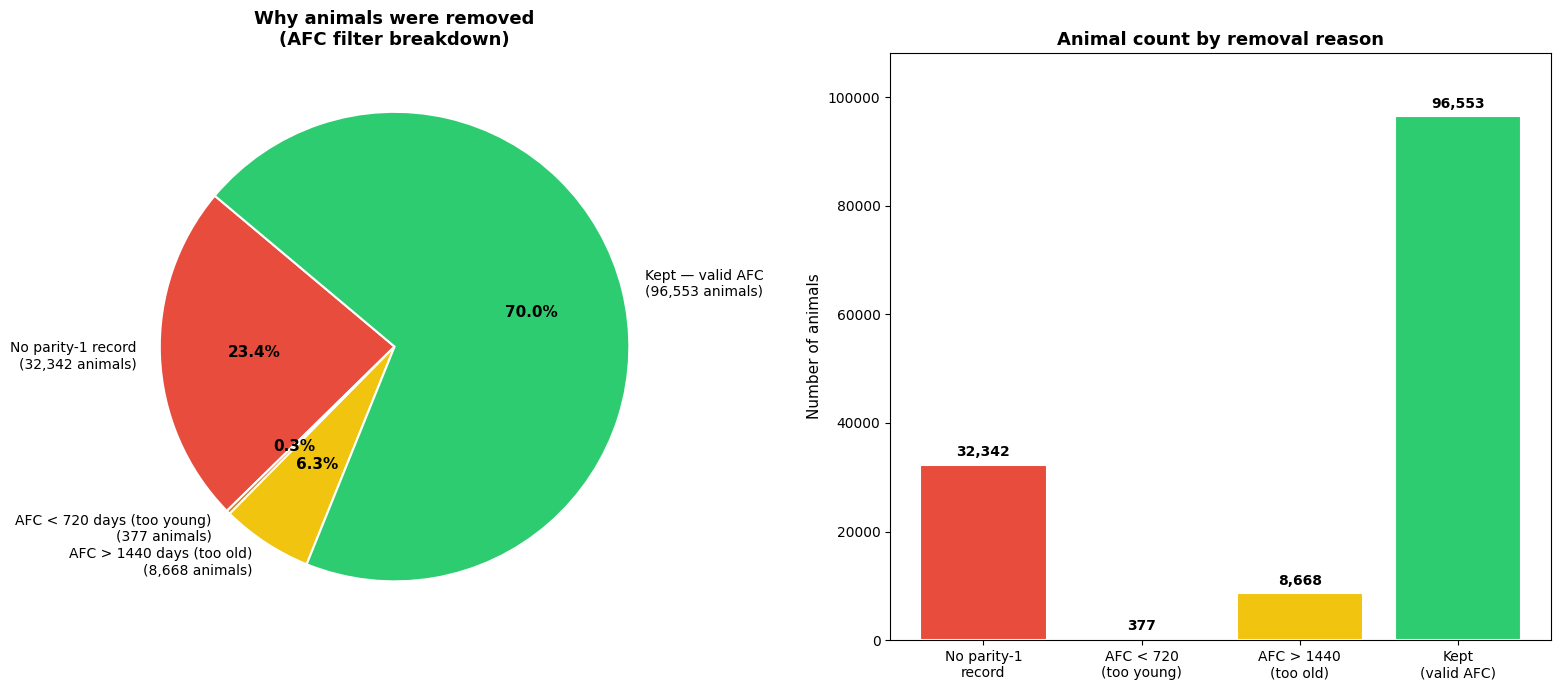

Total animals in NM==2:              137,945
  Kept  — valid AFC at parity 1:     96,553  (70.0%)
  Removed — no parity-1 record:      32,342  (23.4%)
  Removed — AFC < 720 days:           377  (0.3%)
  Removed — AFC > 1440 days:          8,668  (6.3%)


In [88]:
import matplotlib.pyplot as plt

# Work on NM==2 subset (same base as the filter cell above)
base = df[df['NM'] == 2].copy()
all_animals = set(base['Animal_ID'].unique())
kept_animals = set(valid_afc_animals)  # computed in filter cell above
removed_animals = all_animals - kept_animals

# Get each animal's AFC at parity 1
parity1_afc = base[base['parity'] == 1].groupby('Animal_ID')['AFC'].first()

# Categorise removed animals
no_parity1   = [a for a in removed_animals if a not in parity1_afc.index]
afc_too_low  = [a for a in removed_animals if a in parity1_afc.index and parity1_afc[a] < pd.Timedelta(days=720)]
afc_too_high = [a for a in removed_animals if a in parity1_afc.index and parity1_afc[a] > pd.Timedelta(days=1440)]

labels = [
    f'No parity-1 record\n({len(no_parity1):,} animals)',
    f'AFC < 720 days (too young)\n({len(afc_too_low):,} animals)',
    f'AFC > 1440 days (too old)\n({len(afc_too_high):,} animals)',
    f'Kept — valid AFC\n({len(kept_animals):,} animals)',
]
sizes  = [len(no_parity1), len(afc_too_low), len(afc_too_high), len(kept_animals)]
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[0].set_title('Why animals were removed\n(AFC filter breakdown)', fontsize=13, fontweight='bold')

# Bar chart
bar_labels = ['No parity-1\nrecord', 'AFC < 720\n(too young)', 'AFC > 1440\n(too old)', 'Kept\n(valid AFC)']
bars = axes[1].bar(bar_labels, sizes, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Number of animals', fontsize=11)
axes[1].set_title('Animal count by removal reason', fontsize=13, fontweight='bold')
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(sizes) * 0.01,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].set_ylim(0, max(sizes) * 1.12)

plt.tight_layout()
plt.show()

print(f"Total animals in NM==2:              {len(all_animals):,}")
print(f"  Kept  — valid AFC at parity 1:     {len(kept_animals):,}  ({len(kept_animals)/len(all_animals)*100:.1f}%)")
print(f"  Removed — no parity-1 record:      {len(no_parity1):,}  ({len(no_parity1)/len(all_animals)*100:.1f}%)")
print(f"  Removed — AFC < 720 days:           {len(afc_too_low):,}  ({len(afc_too_low)/len(all_animals)*100:.1f}%)")
print(f"  Removed — AFC > 1440 days:          {len(afc_too_high):,}  ({len(afc_too_high)/len(all_animals)*100:.1f}%)")

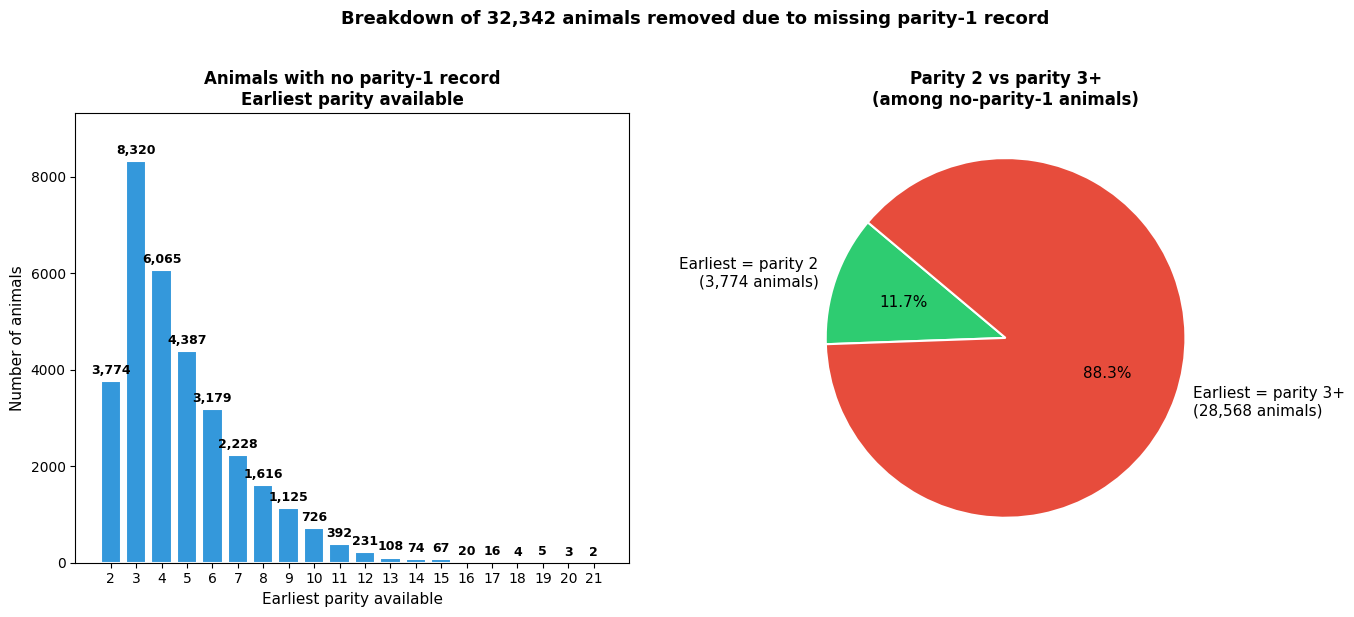

Animals with no parity-1 record:  32,342
  Earliest parity = 2: 3,774 animals (11.7%)
  Earliest parity = 3: 8,320 animals (25.7%)
  Earliest parity = 4: 6,065 animals (18.8%)
  Earliest parity = 5: 4,387 animals (13.6%)
  Earliest parity = 6: 3,179 animals (9.8%)
  Earliest parity = 7: 2,228 animals (6.9%)
  Earliest parity = 8: 1,616 animals (5.0%)
  Earliest parity = 9: 1,125 animals (3.5%)
  Earliest parity = 10: 726 animals (2.2%)
  Earliest parity = 11: 392 animals (1.2%)
  Earliest parity = 12: 231 animals (0.7%)
  Earliest parity = 13: 108 animals (0.3%)
  Earliest parity = 14: 74 animals (0.2%)
  Earliest parity = 15: 67 animals (0.2%)
  Earliest parity = 16: 20 animals (0.1%)
  Earliest parity = 17: 16 animals (0.0%)
  Earliest parity = 18: 4 animals (0.0%)
  Earliest parity = 19: 5 animals (0.0%)
  Earliest parity = 20: 3 animals (0.0%)
  Earliest parity = 21: 2 animals (0.0%)


In [89]:
# Among animals with NO parity-1 record, what parities DO they have?
base = df[df['NM'] == 2].copy()
parity1_afc = base[base['parity'] == 1].groupby('Animal_ID')['AFC'].first()

all_animals    = set(base['Animal_ID'].unique())
kept_animals   = set(valid_afc_animals)
removed_animals = all_animals - kept_animals
no_parity1     = [a for a in removed_animals if a not in parity1_afc.index]

# Get all records of no-parity1 animals and count their minimum parity
no_p1_df = base[base['Animal_ID'].isin(no_parity1)]
min_parity_per_animal = no_p1_df.groupby('Animal_ID')['parity'].min()
parity_counts = min_parity_per_animal.value_counts().sort_index()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bar chart: earliest parity available ---
bars = axes[0].bar(
    parity_counts.index.astype(str),
    parity_counts.values,
    color='#3498db', edgecolor='white', linewidth=1.5
)
axes[0].set_xlabel('Earliest parity available', fontsize=11)
axes[0].set_ylabel('Number of animals', fontsize=11)
axes[0].set_title('Animals with no parity-1 record\nEarliest parity available', fontsize=12, fontweight='bold')
for bar, val in zip(bars, parity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(parity_counts.values)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].set_ylim(0, max(parity_counts.values) * 1.12)

# --- Pie chart: parity 2 vs parity 3+ ---
p2     = parity_counts.get(2, 0)
p3plus = parity_counts[parity_counts.index >= 3].sum()
pie_labels = [f'Earliest = parity 2\n({p2:,} animals)', f'Earliest = parity 3+\n({p3plus:,} animals)']
pie_sizes  = [p2, p3plus]
pie_colors = ['#2ecc71', '#e74c3c']
axes[1].pie(pie_sizes, labels=pie_labels, colors=pie_colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops={'fontsize': 11})
axes[1].set_title('Parity 2 vs parity 3+\n(among no-parity-1 animals)', fontsize=12, fontweight='bold')

plt.suptitle(f'Breakdown of {len(no_parity1):,} animals removed due to missing parity-1 record',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Animals with no parity-1 record:  {len(no_parity1):,}")
for p, cnt in parity_counts.items():
    print(f"  Earliest parity = {int(p)}: {cnt:,} animals ({cnt/len(no_parity1)*100:.1f}%)")

### adding milk and protein lag 

In [90]:
# Lagged target values — these will transform your predictions
df_animal_filtered = df_animal_filtered.sort_values(['Farm_Code', 'Animal_ID', 'dtt'])

df_animal_filtered['milk_kg_lag1']   = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['milk_kg'].shift(1)
df_animal_filtered['milk_kg_lag2']   = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['milk_kg'].shift(2)

df_animal_filtered['protein_p_lag1'] = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['protein_p'].shift(1)
df_animal_filtered['protein_p_lag2'] = df_animal_filtered.groupby(['Farm_Code','Animal_ID'])['protein_p'].shift(2)

## 4. Final Quality Assurance (Outlier Removal)
The final step removes low-density data points to ensure statistical significance:
1.  **Farm Level:** Remove any farms with **< 5 records** per day.
2.  **Animal Level:** Remove any individual animals with **< 3 total test records**.

In [91]:
df_copy = df_animal_filtered.copy()

In [76]:
df_copy.columns

Index(['Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt', 'parity', 'milk_kg',
       'fat_p', 'protein_p', 'cells', 'NM', 'ECM', 'SCS', 'AFC', 'DIM',
       'milk_kg_lag1', 'milk_kg_lag2', 'protein_p_lag1', 'protein_p_lag2'],
      dtype='object')

In [92]:
df_animal_filtered['dtt'] = pd.to_datetime(df_animal_filtered['dtt'])

print("=== BEFORE ===")
print(f"Records:   {len(df_animal_filtered):,}")
print(f"Animals:   {df_animal_filtered['Animal_ID'].nunique():,}")
print(f"Farms:     {df_animal_filtered['Farm_Code'].nunique():,}")
lactations_before = df_animal_filtered.groupby(['Animal_ID','parity']).ngroups
print(f"Lactations:{lactations_before:,}")

# Step 1 — Filter 2: farm-day density
daily_counts = df_animal_filtered.groupby(['Farm_Code', 'dtt'])['Animal_ID'].nunique()
valid_days = daily_counts[daily_counts >= 5]
df = df_animal_filtered.merge(valid_days.rename('day_count').reset_index(), on=['Farm_Code', 'dtt'])
df = df.drop(columns='day_count')

# Step 2 — Filter 1: lactation length
lac_counts = df.groupby(['Farm_Code', 'Animal_ID','parity']).size()
valid_lacs = lac_counts[lac_counts >= 3].reset_index()[['Farm_Code', 'Animal_ID','parity']]
df = df.merge(valid_lacs, on=['Farm_Code', 'Animal_ID','parity'])

print("\n=== AFTER ===")
print(f"Records:   {len(df):,}")
print(f"Animals:   {df['Animal_ID'].nunique():,}")
print(f"Farms:     {df['Farm_Code'].nunique():,}")
lactations_after = df.groupby(['Animal_ID','parity']).ngroups
print(f"Lactations:{lactations_after:,}")



=== BEFORE ===
Records:   1,687,031
Animals:   96,061
Farms:     327
Lactations:269,164

=== AFTER ===
Records:   1,646,809
Animals:   91,221
Farms:     316
Lactations:247,247


## Saving Data To csv

In [93]:
df.to_csv(path+'Final_Data/After_Processing.csv',index=False)

### Parameters Analysis after outlier removal

In [94]:
df_animal_filtered = pd.read_csv(path+'Final_Data/After_Processing.csv')

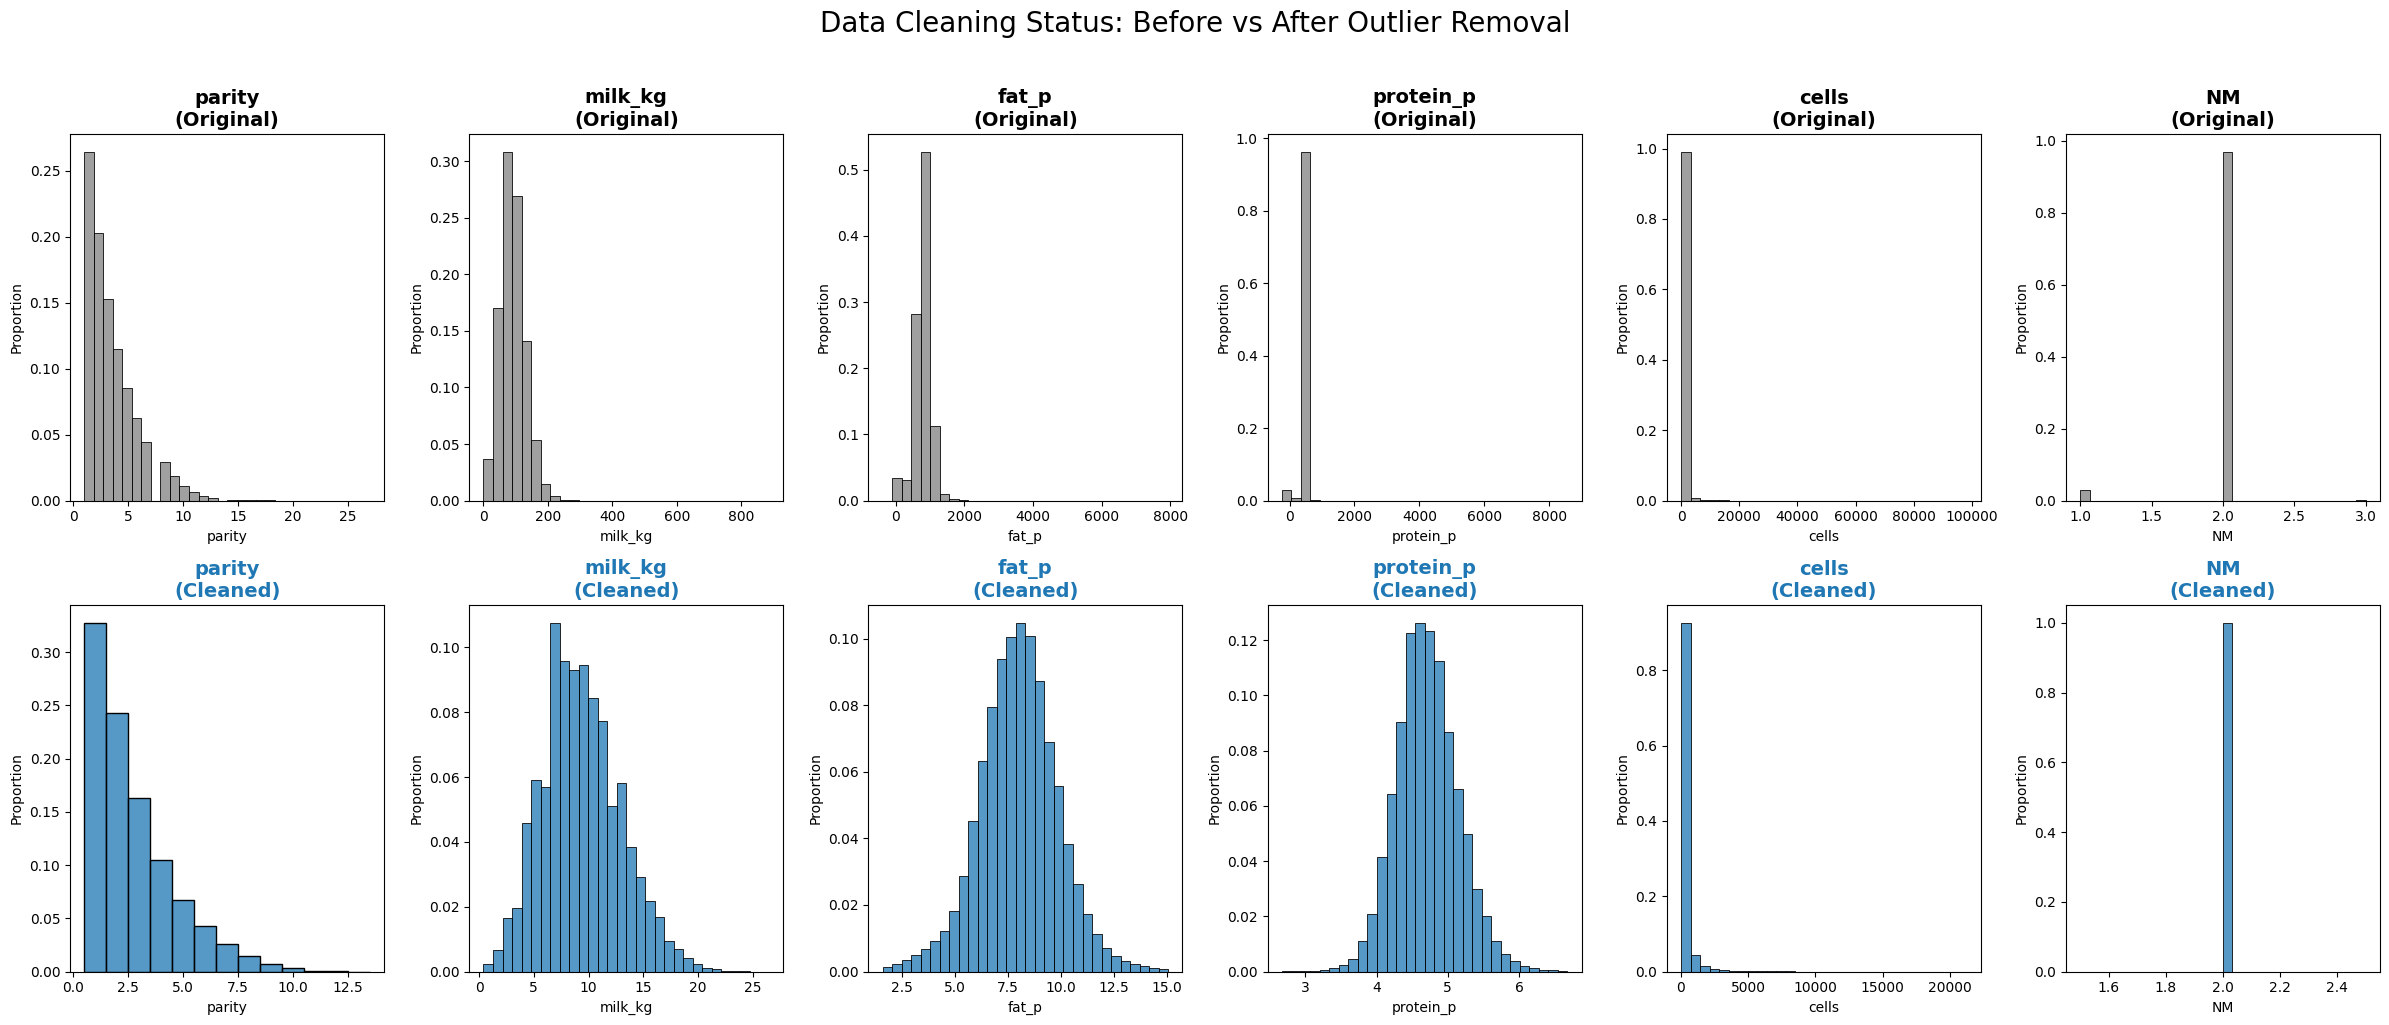

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM']

# Create 2 rows (Top: Before, Bottom: After)
fig, axes = plt.subplots(nrows=2, ncols=len(numerical_cols), figsize=(24, 10))

for i, col in enumerate(numerical_cols):
    # --- TOP ROW: BEFORE (Original Data) ---
    sns.histplot(df_animal[col], ax=axes[0, i], kde=False, 
                 color="grey", bins=30, stat="proportion")
    axes[0, i].set_title(f'{col}\n(Original)', fontsize=14, fontweight='bold')
    axes[0, i].set_ylabel('Proportion')
    
    # --- BOTTOM ROW: AFTER (Cleaned Data) ---
    # Use discrete=True for 'parity' to fix the decimal/comb issue
    is_discrete = True if col == 'parity' else False
    
    sns.histplot(df_animal_filtered[col], ax=axes[1, i], kde=False, 
                 color="#1f77b4", bins=30, stat="proportion", discrete=is_discrete)
    axes[1, i].set_title(f'{col}\n(Cleaned)', fontsize=14, fontweight='bold', color="#1f77b4")
    axes[1, i].set_ylabel('Proportion')

# Add a main title to the whole figure
plt.suptitle('Data Cleaning Status: Before vs After Outlier Removal', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

## Merging all the data together

In [96]:
import pandas as pd
import os
from pathlib import Path
from datetime import datetime

def merge_animal_weather_data(animal_file, weather_folder, output_file):

    print("="*80)
    print("MERGING ANIMAL DATA WITH WEATHER DATA")
    print("="*80)

    # 1. Read the animal data
    print(f"\n1. Reading animal data from: {animal_file}")
    animal_df = pd.read_csv(animal_file)
    print(f"   ✓ Loaded {len(animal_df):,} animal records")
    
    print(f"\n2. Converting 'dtt' column to date format...")
    animal_df['dtt_date'] = pd.to_datetime(animal_df['dtt'], format='mixed', errors='coerce').dt.date

    null_dates = animal_df['dtt_date'].isnull().sum()
    if null_dates > 0:
        print(f"   ⚠ Warning: {null_dates:,} records have invalid dates and will be skipped")

    unique_farms = animal_df['Farm_Code'].unique()
    print(f"   ✓ Found {len(unique_farms)} unique farms in animal data")

    # 2. Load and Transform weather data
    print(f"\n3. Loading and processing weather data files from: {weather_folder}")
    weather_files = list(Path(weather_folder).glob("farm_*_with_indices.csv"))

    if not weather_files:
        print(f"   ✗ ERROR: No weather files found in {weather_folder}")
        return

    # We will store all processed weather DataFrames in a list and concatenate them later
    all_weather_dfs = []

    for weather_file in weather_files:
        try:
            filename = weather_file.stem
            parts = filename.split('_')

            farm_code = None
            for part in parts[1:]:
                clean_part = part.replace('.0', '').replace('.', '')
                if clean_part.isdigit():
                    farm_code = int(clean_part)
                    break

            if farm_code is None:
                continue

            weather_df = pd.read_csv(weather_file)
            weather_df['date'] = pd.to_datetime(weather_df['date']).dt.date
            
            # SORT BY DATE is crucial for accurate shifts and rolling windows
            weather_df = weather_df.sort_values('date').reset_index(drop=True)
            weather_df['Farm_Code'] = farm_code 

            # 1. Temporal Lags (1, 2, 3 days) ONLY for average columns
            # Dynamically grab all columns ending in '_avg'
            avg_columns = [col for col in weather_df.columns if col.endswith('_avg')]
            
            for col in avg_columns:
                weather_df[f'{col}_lag1'] = weather_df[col].shift(1)
                weather_df[f'{col}_lag2'] = weather_df[col].shift(2)
                weather_df[f'{col}_lag3'] = weather_df[col].shift(3).bfill()

            # 2. Composite Index (5-day centered window) for THI averages
            # Look specifically for THI columns in the averages list
            thi_avg_cols = [col for col in avg_columns if 'THI' in col]
            
            for thi_col in thi_avg_cols:
                # Creates column names like 'THI_1_Compose' by stripping out '_avg'
                base_name = thi_col.replace('_avg', '') 
                
                # center=True ensures the window uses (n-2, n-1, n, n+1, n+2)
                weather_df[f'{base_name}_Compose'] = weather_df[thi_col].rolling(window=5, center=True, min_periods=1).mean()

            all_weather_dfs.append(weather_df)
            print(f"   ✓ Processed farm {farm_code}: {len(weather_df)} records")

        except Exception as e:
            print(f"   ✗ Error loading/processing {weather_file.name}: {str(e)}")
            continue

    # Combine all farm weather data into one massive DataFrame
    full_weather_df = pd.concat(all_weather_dfs, ignore_index=True)
    
    farms_with_weather = set(full_weather_df['Farm_Code'].unique())
    farms_in_animal = set(unique_farms)
    farms_missing_weather = farms_in_animal - farms_with_weather

    if farms_missing_weather:
        print(f"\n   ⚠ WARNING: {len(farms_missing_weather)} farms in animal data don't have weather files.")

    # 3. Merge data (Optimized Vectorized Merge)
    print(f"\n4. Merging animal data with weather data (Vectorized)...")
    initial_len = len(animal_df)
    
    # Left Join: keeps all animal records, attaches weather where Farm_Code AND Date match
    merged_df = pd.merge(
        animal_df, 
        full_weather_df, 
        left_on=['Farm_Code', 'dtt_date'], 
        right_on=['Farm_Code', 'date'], 
        how='left'
    )

    # Calculate statistics based on missing 'date' (meaning the join failed for that row)
    matched_records = merged_df['date'].notna().sum()
    no_weather = initial_len - matched_records

    # Clean up redundant columns from the merge
    merged_df = merged_df.drop(['dtt_date', 'date'], axis=1)

    print(f"\n5. Merge Statistics:")
    print(f"   ✓ Successfully matched: {matched_records:,} / {initial_len:,} records ({matched_records/initial_len*100:.1f}%)")
    print(f"   ⚠ Could not match weather/date: {no_weather:,} records")

    # 4. Save merged data
    print(f"\n6. Saving merged data to: {output_file}")
    merged_df.to_csv(output_file, index=False)
    print(f"   ✓ Saved {len(merged_df):,} records")
    print(f"   ✓ Total columns: {len(merged_df.columns)}")

    print("\n" + "="*80)
    print("✓ PROCESS COMPLETE!")
    print("="*80)

    return merged_df

# Set your paths here

animal_file =  path + "Final_Data/After_Processing.csv"
weather_folder = path + "farm_weather_indices"
output_file = path + "Final_Data/Final_Merged_Data.csv"

# Run the merge
merged_data = merge_animal_weather_data(animal_file, weather_folder, output_file)

MERGING ANIMAL DATA WITH WEATHER DATA

1. Reading animal data from: ../Thesis_Data/Final_Data/After_Processing.csv
   ✓ Loaded 1,646,809 animal records

2. Converting 'dtt' column to date format...
   ✓ Found 316 unique farms in animal data

3. Loading and processing weather data files from: ../Thesis_Data/farm_weather_indices
   ✓ Processed farm 5970082: 4749 records
   ✓ Processed farm 7390481: 4749 records
   ✓ Processed farm 1126225: 4749 records
   ✓ Processed farm 7014059: 4749 records
   ✓ Processed farm 7610622: 4749 records
   ✓ Processed farm 6811565: 4749 records
   ✓ Processed farm 7030383: 4749 records
   ✓ Processed farm 5700612: 4749 records
   ✓ Processed farm 6811496: 4749 records
   ✓ Processed farm 5700749: 4749 records
   ✓ Processed farm 5010267: 4749 records
   ✓ Processed farm 6800432: 4749 records
   ✓ Processed farm 5600187: 4749 records
   ✓ Processed farm 5700744: 4749 records
   ✓ Processed farm 6800007: 4749 records
   ✓ Processed farm 7030393: 4749 records